# Fraud Detection Analysis

## Project Objective
This project analyzes financial accounts that tells if you about the accounts.

The goal is to generate an accurate model that can detect if a financial transaction is fraud or not.



# Data Loading

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve

In [3]:
df = pd.read_csv("train_joined.csv")
df.shape

/var/folders/cn/5rls9kg91b35jqphwksc14700000gn/T/ipykernel_43601/2866462557.py:1: DtypeWarning: Columns (406,409,410,417,421,422,423,424,425,427,428,429,430,431,432,433,434) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train_joined.csv")


(590540, 435)

# Data Preparation

In [4]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3002016,0,418018,25.000,H,5014,399.0,150.0,american express,146.0,...,chrome 62.0,24.0,1366x768,match_status:2,True,False,True,True,desktop,Windows
1,3002017,0,418079,200.000,H,5938,111.0,150.0,visa,162.0,...,edge 14.0,24.0,1600x900,match_status:2,True,True,True,True,desktop,Windows
2,3002018,0,418089,50.000,H,2249,343.0,150.0,visa,195.0,...,chrome 62.0,24.0,1440x900,match_status:2,True,False,True,True,desktop,Windows
3,3002021,0,418148,85.555,C,4815,555.0,119.0,visa,226.0,...,chrome 62.0,NaN,NaN,NaN,False,False,True,True,desktop,Windows
4,3002029,0,418235,8.398,C,5812,408.0,185.0,mastercard,224.0,...,firefox 57.0,NaN,NaN,NaN,False,False,True,True,desktop,NaN


In [5]:
df.duplicated().sum()

0

In [6]:
df['TransactionAmt'].describe()
df['TransactionAmt'].sort_values(ascending=False).head(20)

33217     31937.391
33215     31937.391
402876     6450.970
467086     6085.230
484850     5543.230
172930     5420.000
172935     5420.000
511869     5366.820
554215     5279.950
199137     5279.950
326786     5279.950
159804     5278.950
585428     5277.950
336627     5191.000
564552     5191.000
156998     5094.950
565716     5047.470
512315     5001.820
468758     4989.970
183088     4976.310
Name: TransactionAmt, dtype: float64

In [7]:
df['Transaction_day'] = df['TransactionDT'] // (24 * 60 * 60)
df['Transaction_hour'] = (df['TransactionDT'] // 3600) % 24

In [8]:
for col in ['card4', 'card6', 'ProductCD', 'DeviceType']:
    print(col, df[col].unique())

card4 ['american express' 'visa' 'mastercard' 'discover' nan]
card6 ['credit' 'debit' 'debit or credit' nan 'charge card']
ProductCD ['H' 'C' 'R' 'S' 'W']
DeviceType ['desktop' 'mobile' nan]


In [9]:
# From when we read in the csv we can see that the shape of this data is 590540 (rows), 435 (columns)
print ("is null")
df.isnull().sum()

is null


TransactionID            0
isFraud                  0
TransactionDT            0
TransactionAmt           0
ProductCD                0
                     ...  
id_38               449555
DeviceType          449730
DeviceInfo          471874
Transaction_day          0
Transaction_hour         0
Length: 437, dtype: int64

In [10]:
null_pct = df.isnull().mean().sort_values(ascending=False)
null_pct.head(20)

id_24    0.991962
id_25    0.991310
id_08    0.991271
id_07    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_04    0.887689
id_03    0.887689
D6       0.876068
id_33    0.875895
D9       0.873123
dtype: float64

In [11]:
# Since there are so many nulls, we will make an acceptiable threshold of missing data
# if columns are missing more than that threshold they will be dropped
threshold = 0.70
cols_to_drop = null_pct[null_pct > threshold].index
df_clean = df.drop(columns=cols_to_drop)
df_clean.shape

(590540, 228)

In [12]:
# We see that we did get rid of a lot of columns
# all of thoes will have been an anonymized V/id_ columns just aren't going to be usable as-is

# does missingness correlate with fraud?
for col in cols_to_drop[:10]:  # sample check
    print(col, df.groupby(df[col].isnull())['isFraud'].mean())

id_24 id_24
False    0.084685
True     0.034587
Name: isFraud, dtype: float64
id_25 id_25
False    0.081255
True     0.034584
Name: isFraud, dtype: float64
id_08 id_08
False    0.082638
True     0.034570
Name: isFraud, dtype: float64
id_07 id_07
False    0.082638
True     0.034570
Name: isFraud, dtype: float64
id_21 id_21
False    0.082574
True     0.034571
Name: isFraud, dtype: float64
id_26 id_26
False    0.082316
True     0.034573
Name: isFraud, dtype: float64
id_27 id_27
False    0.082414
True     0.034571
Name: isFraud, dtype: float64
id_23 id_23
False    0.082414
True     0.034571
Name: isFraud, dtype: float64
id_22 id_22
False    0.082414
True     0.034571
Name: isFraud, dtype: float64
dist2 dist2
False    0.099158
True     0.030623
Name: isFraud, dtype: float64


When checking fraud rate grouped by whether each id_ column (and dist2) was null or not, the fraud rate was roughly twice as high in rows where the field was present compared to rows where it was missing. Even though both percentages are low in absolute terms, that consistent ~2x gap across multiple columns suggests missingness itself carries information related to fraud — a correlation, not a proven causal reason. Because of this, instead of dropping these high-null columns outright, I kept a binary 'was this field present' flag so the model could still use that signal.

In [13]:
# Columns where missingness itself was predictive of fraud
meaningful_missing_cols = ['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 
                            'id_26', 'id_27', 'id_23', 'id_22', 'dist2']

# Create presence flags from the ORIGINAL df (before anything was dropped)
for col in meaningful_missing_cols:
    df_clean[f'{col}_was_present'] = df[col].notnull().astype(int)

df_clean.shape

(590540, 238)

I want to go back through and make sure that the other columns I dropped do not have the same weight in the prediction. While all 435 columns is a lot, I would prefer to not get rid of a column if I think it will help. 

In [14]:
# Check fraud rate by null/not-null for ALL dropped columns
missingness_fraud_check = {}

for col in cols_to_drop:
    rates = df.groupby(df[col].isnull())['isFraud'].mean()
    if True in rates.index and False in rates.index:
        missingness_fraud_check[col] = {
            'fraud_rate_present': rates[False],
            'fraud_rate_missing': rates[True],
            'ratio': rates[False] / rates[True] if rates[True] > 0 else float('inf')
        }

missingness_df = pd.DataFrame(missingness_fraud_check).T
missingness_df = missingness_df.sort_values('ratio', ascending=False)
missingness_df

,fraud_rate_present,fraud_rate_missing,ratio
D7,0.148778,0.026962,5.518017
D12,0.117403,0.024847,4.725101
D14,0.115989,0.025456,4.556362
D13,0.110360,0.026156,4.219209
D6,0.105456,0.025022,4.214594
...,...,...,...
V157,0.044542,0.033451,1.331563
V139,0.044542,0.033451,1.331563
V162,0.044542,0.033451,1.331563
id_32,0.044480,0.033555,1.325588


In [15]:
# Flag columns where the ratio is notably different from 1
# (ratio near 1 = no real difference; ratio far from 1 = missingness matters)
meaningful_cols = missingness_df[(missingness_df['ratio'] > 1.5) | (missingness_df['ratio'] < 0.67)]
meaningful_cols

,fraud_rate_present,fraud_rate_missing,ratio
D7,0.148778,0.026962,5.518017
D12,0.117403,0.024847,4.725101
D14,0.115989,0.025456,4.556362
D13,0.110360,0.026156,4.219209
D6,0.105456,0.025022,4.214594
...,...,...,...
id_27,0.082414,0.034571,2.383901
id_23,0.082414,0.034571,2.383901
id_22,0.082414,0.034571,2.383901
id_26,0.082316,0.034573,2.380975


In [16]:
meaningful_missing_cols = meaningful_cols.index.tolist()

for col in meaningful_missing_cols:
    df_clean[f'{col}_was_present'] = df[col].notnull().astype(int)

df_clean.shape

/var/folders/cn/5rls9kg91b35jqphwksc14700000gn/T/ipykernel_43601/2597756308.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[f'{col}_was_present'] = df[col].notnull().astype(int)
/var/folders/cn/5rls9kg91b35jqphwksc14700000gn/T/ipykernel_43601/2597756308.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[f'{col}_was_present'] = df[col].notnull().astype(int)
/var/folders/cn/5rls9kg91b35jqphwksc14700000gn/T/ipykernel_43601/2597756308.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually t

(590540, 385)

383 is still a large amount of collumns, instead of indivudually checking them lets straightforward baseline of what we know right now is inportant to the model.

 # Modeling

In [17]:
# Seperate target and features
X = df_clean.drop(columns=['isFraud', 'TransactionID']) # TransactionID is just an identifier, not a real feature,
y = df_clean['isFraud']

In [18]:
#  Identify categorical vs numeric colum
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f"{len(cat_cols)} categorical columns")
print(f"{len(num_cols)} numeric columns")

13 categorical columns
370 numeric columns


In [19]:
# Encode categoricals
X_encoded = X.copy()
for col in cat_cols:
    X_encoded[col] = X_encoded[col].astype(str)  # handles NaN safely as a string category
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='auc',
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
y_pred_proba = model.predict_proba(X_val)[:, 1]

print("ROC AUC:", roc_auc_score(y_val, y_pred_proba))
print("PR AUC:", average_precision_score(y_val, y_pred_proba))

ROC AUC: 0.9352139051467421
PR AUC: 0.6800810350765923


In [23]:
importances = pd.Series(model.feature_importances_, index=X_encoded.columns)
importances = importances.sort_values(ascending=False)
importances.head(30)

C7                           0.089666
V45                          0.064270
V91                          0.055357
V295                         0.044211
V94                          0.040975
C8                           0.030937
V70                          0.030574
V80                          0.026985
C14                          0.026445
V40                          0.025921
V317                         0.021667
C1                           0.019752
V308                         0.016983
V283                         0.015740
R_emaildomain_was_present    0.014482
C4                           0.010489
V29                          0.010372
V48                          0.009179
C12                          0.009129
V279                         0.009073
addr2                        0.008814
V79                          0.007722
V62                          0.007468
card6                        0.006963
V20                          0.006903
D2                           0.006798
C11         

In [24]:
top_features = importances.head(120).index.tolist()

X_train_top = X_train[top_features]
X_val_top = X_val[top_features]

model_top = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='auc',
    random_state=42
)
model_top.fit(X_train_top, y_train)

y_pred_proba_top = model_top.predict_proba(X_val_top)[:, 1]
print("ROC AUC (top 120):", roc_auc_score(y_val, y_pred_proba_top))
print("PR AUC (top 120):", average_precision_score(y_val, y_pred_proba_top))

ROC AUC (top 120): 0.9359931583894512
PR AUC (top 120): 0.6796194229613498


I evaluated feature subsets at 50, 100, and 120 features (ranked by XGBoost feature importance) and found that 120 features produced the best balance of ROC AUC and PR AUC — outperforming even the full 383-feature model, while reducing dimensionality by roughly 69%

In [25]:
# Save the list of those 120 columns so it's reproducible and you're not re-running every time

final_features = importances.head(120).index.tolist()

import json
with open('final_features.json', 'w') as f:
    json.dump(final_features, f)

# Evaluation

It's worth checking for columns that technically have data but barely vary at all (e.g., 99.9% one value)
That way we know that all columns we have are working for us without adding anything that may be deemed not important

In [26]:
# Checking constant / near-zero-variance columns
low_variance = X_encoded.nunique()
low_variance[low_variance <= 1]

Series([], dtype: int64)

[[113752    223]
 [  2283   1850]]


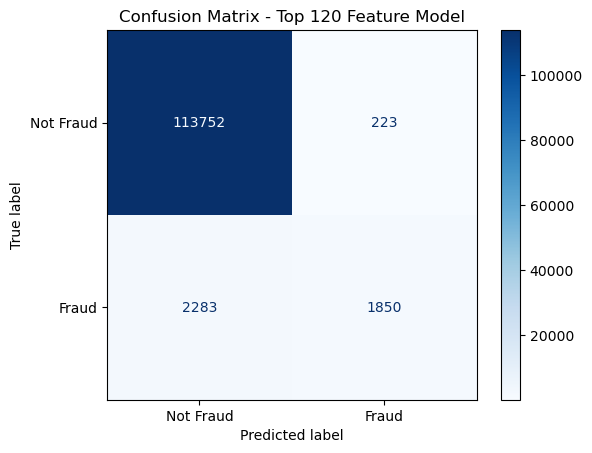

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.89      0.45      0.60      4133

    accuracy                           0.98    118108
   macro avg       0.94      0.72      0.79    118108
weighted avg       0.98      0.98      0.98    118108



In [29]:
y_pred_top = (y_pred_proba_top >= 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred_top)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Top 120 Feature Model')
plt.show()

print(classification_report(y_val, y_pred_top))

What the confusion matrix is telling us about the fruad class (the first row)
- When the model flags something as fraud, it's right 89% of the time. Not drowning legitimate customers in false alarms.
- Model is only catching 45% of actual fraud cases. Not great.
This means the model is technically working, but that it can do a lot better.

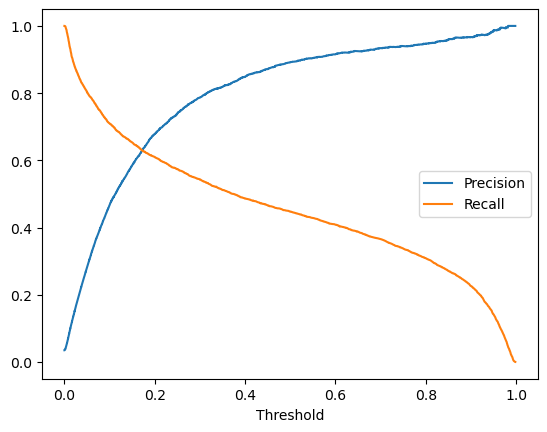

In [30]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba_top)

# Plot precision and recall against threshold to see the tradeoff
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

In [31]:
# Since the threshholds corss at 0.2, I want to see 0.0-0.2 threshold in an exact answer instead of reading it off a chart
threshold = 0.10
y_pred_thresh = (y_pred_proba_top >= threshold).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score
print("Precision:", precision_score(y_val, y_pred_thresh))
print("Recall:", recall_score(y_val, y_pred_thresh))
print("F1:", f1_score(y_val, y_pred_thresh))

Precision: 0.4667620865139949
Recall: 0.7101379143479313
F1: 0.5632856731599655


In [32]:
thresholds_to_test = np.arange(0.05, 0.55, 0.05)
for t in thresholds_to_test:
    preds = (y_pred_proba_top >= t).astype(int)
    p = precision_score(y_val, preds)
    r = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    print(f"Threshold {t:.2f}: Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")

Threshold 0.05: Precision=0.281, Recall=0.803, F1=0.416
Threshold 0.10: Precision=0.467, Recall=0.710, F1=0.563
Threshold 0.15: Precision=0.585, Recall=0.653, F1=0.617
Threshold 0.20: Precision=0.679, Recall=0.610, F1=0.643
Threshold 0.25: Precision=0.739, Recall=0.574, F1=0.646
Threshold 0.30: Precision=0.787, Recall=0.543, F1=0.643
Threshold 0.35: Precision=0.819, Recall=0.512, F1=0.630
Threshold 0.40: Precision=0.849, Recall=0.486, F1=0.618
Threshold 0.45: Precision=0.871, Recall=0.466, F1=0.607
Threshold 0.50: Precision=0.892, Recall=0.448, F1=0.596


Above I evaluated F1-score across thresholds from 0.05 to 0.50 to find the optimal classification cutoff. Performance peaked at threshold 0.25, achieving 73.9% precision and 57.4% recall (F1 = 0.646) — a meaningfully better balance than the default 0.5 threshold, which only achieved 44.8% recall despite higher precision.

[[112781   1194]
 [  1611   2522]]


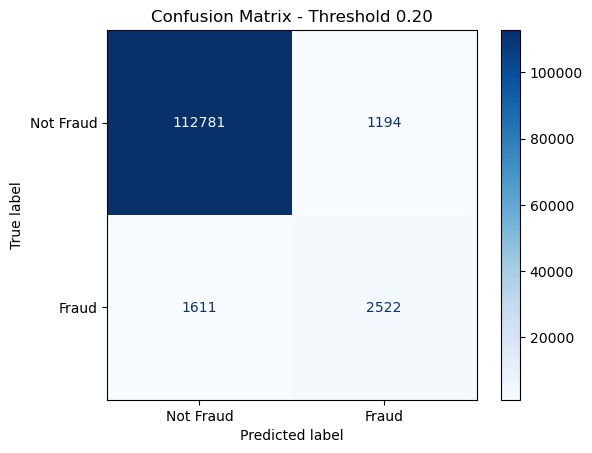

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.68      0.61      0.64      4133

    accuracy                           0.98    118108
   macro avg       0.83      0.80      0.82    118108
weighted avg       0.98      0.98      0.98    118108



In [33]:
y_pred_020 = (y_pred_proba_top >= 0.20).astype(int)

cm = confusion_matrix(y_val, y_pred_020)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Threshold 0.20')
plt.show()

print(classification_report(y_val, y_pred_020))

I chose to weight recall more heavily than the default threshold, based on the reasoning that missed fraud typically carries a higher direct financial cost than a false alarm. However, I avoided the most extreme recall-maximizing thresholds (like 0.05) because the resulting flood of false positives would likely overwhelm a real review process and erode customer trust.

Accuracy: 0.98
This is simply: (correct predictions) / (total predictions). Out of all 118,108 transactions in the validation set, the model got 98% of them right — meaning correctly said "fraud" or correctly said "not fraud."
The catch: accuracy treats every prediction equally, regardless of which class it belongs to. Since the data is about 96.5% legitimate transactions, a model that just guessed "not fraud" for everything, never even looking at the data, would still score around 96% accuracy — while being completely useless. That's exactly why accuracy is a misleading headline number for imbalanced data like fraud: it's dominated by how well you do on the class that barely needs help (the huge "not fraud" group), and can hide how badly you're doing on the class you actually care about.

Macro avg: 0.82 (for F1, in the report)
This takes the F1-score for class 0 (0.99) and the F1-score for class 1 (0.64), and averages them treating both classes as equally important, regardless of size. 
This is the metric that actually reflects "how well are you doing on both classes," not just the big one. Macro avg is saying something accuracy was hiding: the fraud-class performance (0.64) is dragging the true balanced picture down, even though it barely dents the accuracy number.

Weighted avg: 0.98 (for F1, in the report)
This also averages the two classes' F1-scores, but instead of treating them equally, it weights each by how many examples are actually in that class (its "support"). Since class 0 has  abot 27x more examples than class 1, weighted avg is almost entirely driven by how well the model dose on the majority class. 

In [34]:
cm = confusion_matrix(y_val, y_pred_020)

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (correctly identified as NOT fraud):  {tn}")
print(f"False Positives (flagged as fraud, but legitimate):  {fp}")
print(f"False Negatives (missed fraud):                      {fn}")
print(f"True Positives (correctly caught fraud):              {tp}")
print()
print(f"Total fraud cases in validation set: {fn + tp}")
print(f"Fraud caught: {tp} out of {fn + tp} ({tp/(fn+tp)*100:.1f}%)")
print(f"Fraud missed: {fn} out of {fn + tp} ({fn/(fn+tp)*100:.1f}%)")
print(f"Legitimate transactions incorrectly flagged: {fp} out of {tn + fp} ({fp/(tn+fp)*100:.2f}%)")

True Negatives (correctly identified as NOT fraud):  112781
False Positives (flagged as fraud, but legitimate):  1194
False Negatives (missed fraud):                      1611
True Positives (correctly caught fraud):              2522

Total fraud cases in validation set: 4133
Fraud caught: 2522 out of 4133 (61.0%)
Fraud missed: 1611 out of 4133 (39.0%)
Legitimate transactions incorrectly flagged: 1194 out of 113975 (1.05%)


[[105460   8515]
 [   813   3320]]


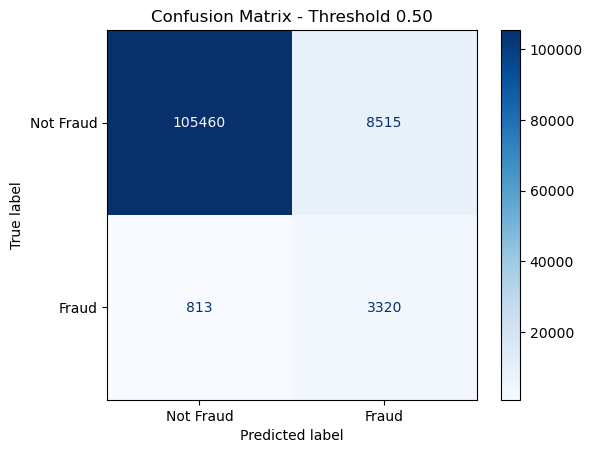

              precision    recall  f1-score   support

           0       0.99      0.93      0.96    113975
           1       0.28      0.80      0.42      4133

    accuracy                           0.92    118108
   macro avg       0.64      0.86      0.69    118108
weighted avg       0.97      0.92      0.94    118108



In [37]:
y_pred_005 = (y_pred_proba_top >= 0.05).astype(int)

cm = confusion_matrix(y_val, y_pred_005)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Threshold 0.50')
plt.show()

print(classification_report(y_val, y_pred_050))

In [38]:
m = confusion_matrix(y_val, y_pred_005)

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (correctly identified as NOT fraud):  {tn}")
print(f"False Positives (flagged as fraud, but legitimate):  {fp}")
print(f"False Negatives (missed fraud):                      {fn}")
print(f"True Positives (correctly caught fraud):              {tp}")
print()
print(f"Total fraud cases in validation set: {fn + tp}")
print(f"Fraud caught: {tp} out of {fn + tp} ({tp/(fn+tp)*100:.1f}%)")
print(f"Fraud missed: {fn} out of {fn + tp} ({fn/(fn+tp)*100:.1f}%)")
print(f"Legitimate transactions incorrectly flagged: {fp} out of {tn + fp} ({fp/(tn+fp)*100:.2f}%)")

True Negatives (correctly identified as NOT fraud):  105460
False Positives (flagged as fraud, but legitimate):  8515
False Negatives (missed fraud):                      813
True Positives (correctly caught fraud):              3320

Total fraud cases in validation set: 4133
Fraud caught: 3320 out of 4133 (80.3%)
Fraud missed: 813 out of 4133 (19.7%)
Legitimate transactions incorrectly flagged: 8515 out of 113975 (7.47%)


As a customer I wanted to see what it would look like if there was more of a chance to get flagged when there is fraud, that meant changing the threshhold around and seeing what else would happen. 
At threshold 0.05, there's a 7.47% chance your legitimate transaction gets wrongly flagged as fraud. That's about 1 in every 13 real transactions getting blocked, delayed, or triggering a "was this really you?" text. At threshold 0.20, that risk drops to about 1 in 95 legitimate transactions. As an actual customer experiencing this, getting flagged 1-in-13 times you swipe your card would likely feel pretty disruptive. 
S0 there should be choices clearly explained to the customer. 
Rather than a single fixed threshold, a bank could offer opt-in tiered security: customers who want maximum fraud protection could be flagged at a lower threshold (like 0.05) and receive a text confirmation for borderline transactions, accepting more frequent verification in exchange for higher fraud-catch rates. Customers less concerned about occasional false alarms could remain at a threshold like 0.20, prioritizing convenience.